<a href="https://colab.research.google.com/github/apester/TDA/blob/main/TDA_Lecture_4_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TDA Lecture 4 — TDA Meets Deep Learning and NLP

This notebook accompanies **Lecture 4: TDA meets deep learning and NLP**.

It follows the three bridges from the lecture:

1. **Topology as input features**
2. **Topology as part of the loss / training objective**
3. **Topology as a way to inspect learned representations**

It also ends with a small **NLP embedding geometry** demo.

---
**Pedagogical note:** this notebook uses light-weight, classroom-friendly code.  
For real persistent homology pipelines, one would typically use libraries such as `ripser`, `gudhi`, or `giotto-tda`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors

## 1. A tiny helper toolkit

To keep the notebook self-contained, we define a few helper functions:

- pairwise distances
- k-nearest-neighbor graph
- connected components
- simple Betti-0 style summaries
- a crude loop score for point clouds

These are **didactic approximations**, not replacements for full persistence pipelines.

In [2]:
def pairwise_distances(X):
    X = np.asarray(X, dtype=float)
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt(np.sum(diff**2, axis=-1))

def knn_graph(X, k=6):
    X = np.asarray(X, dtype=float)
    nbrs = NearestNeighbors(n_neighbors=min(k+1, len(X))).fit(X)
    distances, indices = nbrs.kneighbors(X)
    edges = set()
    for i in range(len(X)):
        for j in indices[i][1:]:
            a, b = sorted((i, int(j)))
            edges.add((a, b))
    return sorted(edges)

def connected_components(n, edges):
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in edges:
        union(a, b)

    groups = {}
    for i in range(n):
        r = find(i)
        groups.setdefault(r, []).append(i)
    return list(groups.values())

def count_triangles(n, edges):
    edge_set = set(tuple(sorted(e)) for e in edges)
    c = 0
    for i, j, k in combinations(range(n), 3):
        if ((i, j) in edge_set and (i, k) in edge_set and (j, k) in edge_set):
            c += 1
    return c

def cycle_rank(n, edges):
    comps = len(connected_components(n, edges))
    return len(edges) - n + comps

def crude_topology_features(X, k=6):
    edges = knn_graph(X, k=k)
    n = len(X)
    comps = len(connected_components(n, edges))
    triangles = count_triangles(n, edges)
    c_rank = cycle_rank(n, edges)
    avg_deg = 2 * len(edges) / n
    return {
        "n_points": n,
        "edges": len(edges),
        "components": comps,
        "cycle_rank": c_rank,
        "triangles": triangles,
        "avg_degree": avg_deg,
    }

## 2. Bridge 1 — Topology as an input feature

The lecture’s first bridge says:

> compute persistence or topological summaries from the data, then feed them into a downstream model.

We will simulate that idea by generating several 2D point clouds and extracting a few structural descriptors.

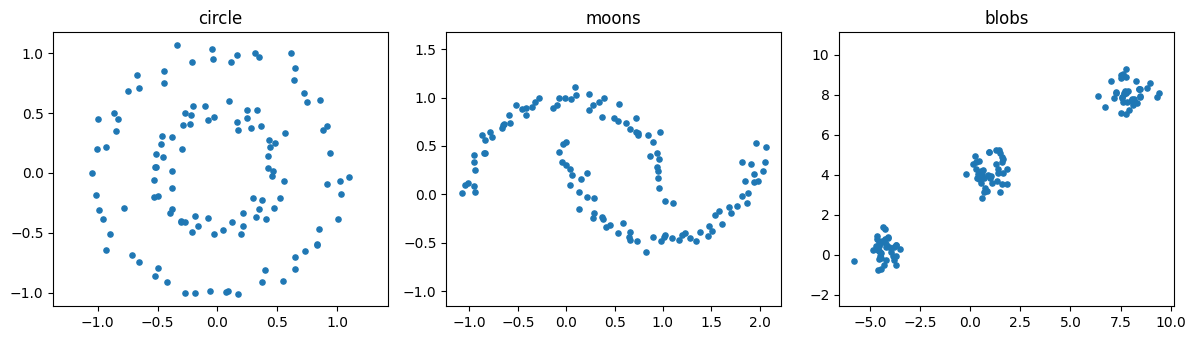

In [3]:
def sample_shape(kind, n=120, noise=0.06, random_state=0):
    if kind == "circle":
        X, _ = make_circles(n_samples=n, factor=0.5, noise=noise, random_state=random_state)
        return X
    if kind == "moons":
        X, _ = make_moons(n_samples=n, noise=noise, random_state=random_state)
        return X
    if kind == "blobs":
        X, _ = make_blobs(n_samples=n, centers=3, cluster_std=0.55, random_state=random_state)
        return X
    raise ValueError("Unknown kind")

shapes = ["circle", "moons", "blobs"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, s in zip(axes, shapes):
    X = sample_shape(s, random_state=3)
    ax.scatter(X[:,0], X[:,1], s=14)
    ax.set_title(s)
    ax.axis("equal")
plt.tight_layout()
plt.show()

In [4]:
for s in shapes:
    X = sample_shape(s, random_state=3)
    feats = crude_topology_features(X, k=6)
    print(s, feats)

circle {'n_points': 120, 'edges': 400, 'components': 1, 'cycle_rank': 281, 'triangles': 482, 'avg_degree': 6.666666666666667}
moons {'n_points': 120, 'edges': 403, 'components': 1, 'cycle_rank': 284, 'triangles': 524, 'avg_degree': 6.716666666666667}
blobs {'n_points': 120, 'edges': 466, 'components': 3, 'cycle_rank': 349, 'triangles': 656, 'avg_degree': 7.766666666666667}


Even these crude features already separate different geometric organizations:

- **circle** often produces a stronger loop-like signature
- **blobs** tends to emphasize clustered connectivity
- **moons** sits somewhere between separated clusters and curved manifolds

In full TDA, we would replace these hand-built descriptors by persistence diagrams, landscapes, images, or other vectorizations.

In [5]:
# Build a simple classification task:
# label 1 = circle-like, label 0 = non-circle
Xtab = []
ytab = []

for seed in range(80):
    X_circle = sample_shape("circle", random_state=seed)
    f = crude_topology_features(X_circle, k=6)
    Xtab.append(list(f.values()))
    ytab.append(1)

    X_moons = sample_shape("moons", random_state=seed)
    f = crude_topology_features(X_moons, k=6)
    Xtab.append(list(f.values()))
    ytab.append(0)

    X_blobs = sample_shape("blobs", random_state=seed)
    f = crude_topology_features(X_blobs, k=6)
    Xtab.append(list(f.values()))
    ytab.append(0)

Xtab = np.array(Xtab, dtype=float)
ytab = np.array(ytab)

X_train, X_test, y_train, y_test = train_test_split(Xtab, ytab, test_size=0.25, random_state=42)
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("Feature names:", list(crude_topology_features(sample_shape('circle')).keys()))
print("Coefficients:", clf.coef_)

Accuracy: 1.0
Feature names: ['n_points', 'edges', 'components', 'cycle_rank', 'triangles', 'avg_degree']
Coefficients: [[ 0.37294428  0.4431908  -0.01829486  0.05195166 -0.46475545  0.00738651]]


### Interpretation

This tiny experiment illustrates the idea of **topology as input features**:

- geometry/topology is summarized first
- a standard model consumes those summaries
- the downstream learner benefits from global structural clues

That is the simplest bridge between TDA and deep learning pipelines.

## 3. Bridge 2 — Topology in the loss function

Lecture 4 emphasizes that topology can enter **optimization directly**.

A full topological loss is mathematically more sophisticated, but the central intuition is simple:

- if the target should be one connected object with no holes,
- then the loss should penalize extra components or spurious holes.

We will create a toy segmentation-like example on a grid.

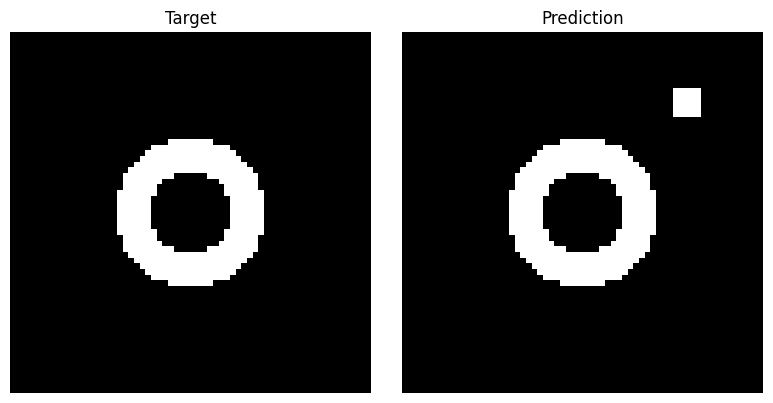

In [6]:
def make_ring_mask(n=64, r_inner=0.23, r_outer=0.42):
    xs = np.linspace(-1, 1, n)
    ys = np.linspace(-1, 1, n)
    Xg, Yg = np.meshgrid(xs, ys)
    R = np.sqrt(Xg**2 + Yg**2)
    mask = ((R >= r_inner) & (R <= r_outer)).astype(float)
    return mask

target = make_ring_mask()

# imperfect prediction with a broken ring and spurious blob
pred = target.copy()
pred[28:36, 29:34] = 0.0
pred[10:15, 48:53] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target, cmap="gray")
axes[0].set_title("Target")
axes[1].imshow(pred, cmap="gray")
axes[1].set_title("Prediction")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
def grid_edges(binary_img):
    H, W = binary_img.shape
    edges = []
    idx = lambda r, c: r * W + c
    for r in range(H):
        for c in range(W):
            if binary_img[r, c] == 0:
                continue
            for dr, dc in [(1, 0), (0, 1)]:
                rr, cc = r + dr, c + dc
                if rr < H and cc < W and binary_img[rr, cc] == 1:
                    edges.append((idx(r, c), idx(rr, cc)))
    return edges

def binary_component_count(binary_img):
    inds = np.argwhere(binary_img > 0)
    if len(inds) == 0:
        return 0
    mapping = {tuple(rc): i for i, rc in enumerate(map(tuple, inds))}
    edges = []
    for r, c in inds:
        for dr, dc in [(1,0), (0,1)]:
            rr, cc = r + dr, c + dc
            if (rr, cc) in mapping:
                edges.append((mapping[(r,c)], mapping[(rr,cc)]))
    return len(connected_components(len(inds), edges))

pixel_loss = np.mean((pred - target)**2)
target_components = binary_component_count(target)
pred_components = binary_component_count(pred)

topology_penalty = abs(pred_components - target_components)
total_loss = pixel_loss + 0.5 * topology_penalty

print("Pixel loss:", pixel_loss)
print("Target components:", target_components)
print("Prediction components:", pred_components)
print("Topology penalty:", topology_penalty)
print("Toy total loss:", total_loss)

Pixel loss: 0.006103515625
Target components: 1
Prediction components: 2
Topology penalty: 1
Toy total loss: 0.506103515625


### Why this matters

A pixel-wise loss may say the prediction is “not too bad”.

But at the object level, the prediction is wrong:
- the ring is broken
- an extra connected object appears

This is exactly the kind of situation where **topology-aware losses** are attractive, especially in:
- medical image segmentation
- shape reconstruction
- scientific imaging

## 4. Bridge 3 — Topology of latent representations

Now we move from outputs to **representation spaces**.

Question:
> Does a learned embedding preserve the important structural relations of the input?

We mimic an encoder by compressing data with PCA and compare the topology of the original space and the latent space.

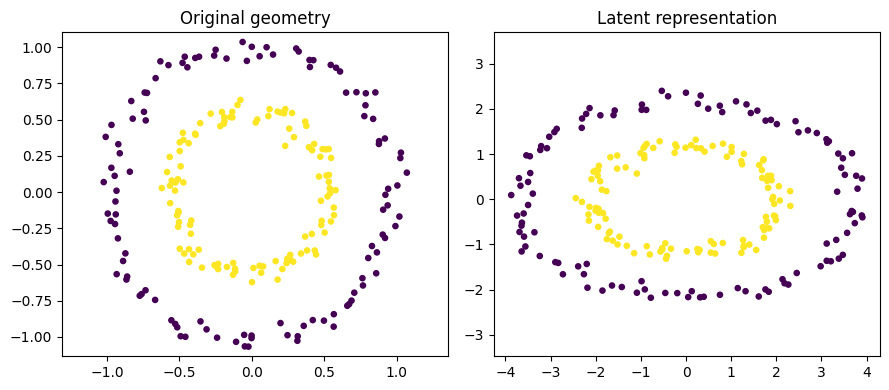

In [8]:
X_high, y_high = make_circles(n_samples=220, factor=0.55, noise=0.05, random_state=7)

# embed the 2D data into a higher-dimensional ambient space
rng = np.random.default_rng(7)
A = rng.normal(size=(2, 12))
X_ambient = X_high @ A + 0.03 * rng.normal(size=(len(X_high), 12))

# linear latent representation
Z = PCA(n_components=2).fit_transform(X_ambient)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(X_high[:,0], X_high[:,1], c=y_high, s=14)
axes[0].set_title("Original geometry")
axes[0].axis("equal")

axes[1].scatter(Z[:,0], Z[:,1], c=y_high, s=14)
axes[1].set_title("Latent representation")
axes[1].axis("equal")
plt.tight_layout()
plt.show()

In [9]:
orig_feats = crude_topology_features(X_high, k=8)
latent_feats = crude_topology_features(Z, k=8)

print("Original features:", orig_feats)
print("Latent features:  ", latent_feats)

Original features: {'n_points': 220, 'edges': 957, 'components': 1, 'cycle_rank': 738, 'triangles': 1703, 'avg_degree': 8.7}
Latent features:   {'n_points': 220, 'edges': 981, 'components': 1, 'cycle_rank': 762, 'triangles': 1754, 'avg_degree': 8.918181818181818}


### Discussion

If the latent representation preserves:
- connectivity,
- cluster relations,
- loop-like structure,

then it is often a better representation for:
- downstream classification
- anomaly detection
- generation
- interpretation

This is the motivation behind **topological autoencoders** and related representation-regularization ideas.

## 5. Higher-order neural networks: beyond pairwise graphs

The lecture also mentions that topology is not only a summary tool.

Sometimes it defines the **domain of computation** itself.

Graph neural networks model vertices and edges.
Simplicial or cell-complex networks model **higher-order interactions** such as triangles or group relations.

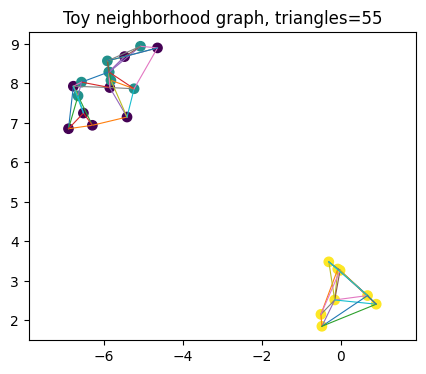

In [10]:
# Simple toy example: pairwise graph vs higher-order motif count
X_bl, labels = make_blobs(n_samples=24, centers=3, cluster_std=0.8, random_state=5)
edges = knn_graph(X_bl, k=4)
triangles = count_triangles(len(X_bl), edges)

plt.figure(figsize=(5, 4))
plt.scatter(X_bl[:,0], X_bl[:,1], c=labels, s=45)
for a, b in edges:
    plt.plot([X_bl[a,0], X_bl[b,0]], [X_bl[a,1], X_bl[b,1]], linewidth=0.8)
plt.title(f"Toy neighborhood graph, triangles={triangles}")
plt.axis("equal")
plt.show()

Triangles are important because they indicate **three-way relations**, not just pairwise links.

Examples:
- co-authorship groups
- triadic social motifs
- multi-agent coordination
- higher-order biological interactions

That is the conceptual entry point to simplicial deep learning.

## 6. TDA and NLP embeddings

Lecture 4 points out that TDA is often **diagnostic** in NLP rather than directly predictive.

We will build a toy embedding space with three semantic groups:
- animals
- fruits
- vehicles

Then we inspect the geometry.

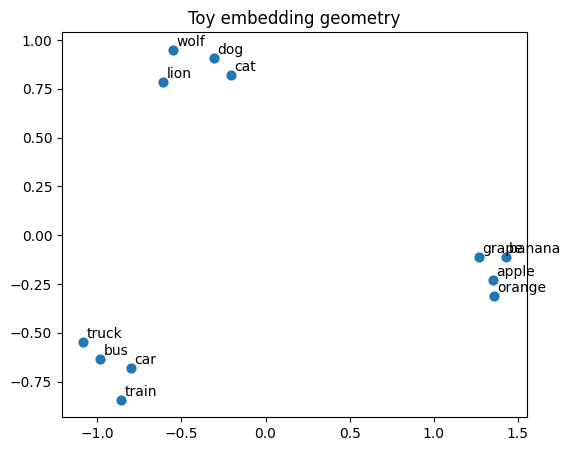

In [11]:
tokens = [
    "cat","dog","wolf","lion",
    "apple","banana","orange","grape",
    "car","bus","train","truck"
]

emb = np.array([
    [0.9,  0.2,  0.1],
    [1.0,  0.1,  0.0],
    [1.2,  0.0,  0.2],
    [1.1, -0.1,  0.3],
    [-0.8,  1.0,  0.0],
    [-0.7,  1.2,  0.1],
    [-0.9,  0.9, -0.1],
    [-0.6,  1.1,  0.2],
    [0.0, -0.8,  1.0],
    [0.1, -1.0,  0.9],
    [-0.1, -0.9,  1.1],
    [0.2, -1.1,  0.8],
], dtype=float)

Z_nlp = PCA(n_components=2).fit_transform(emb)

plt.figure(figsize=(6, 5))
plt.scatter(Z_nlp[:,0], Z_nlp[:,1], s=40)
for i, tok in enumerate(tokens):
    plt.text(Z_nlp[i,0] + 0.02, Z_nlp[i,1] + 0.02, tok, fontsize=10)
plt.title("Toy embedding geometry")
plt.show()

In [12]:
nlp_feats = crude_topology_features(Z_nlp, k=3)
nlp_feats

{'n_points': 12,
 'edges': 18,
 'components': 3,
 'cycle_rank': 9,
 'triangles': 12,
 'avg_degree': 3.0}

### What topology can contribute here

TDA can help analyze:

- semantic clusters
- loops or branching structure in embedding neighborhoods
- layer-wise changes across models
- geometry shifts after fine-tuning

In real NLP workflows, one could compare:
- different layers of a transformer
- base vs fine-tuned embeddings
- in-domain vs out-of-domain text sets

## 7. Mini research prompts

1. When is topology more useful as a **feature**, and when more useful as a **constraint**?
2. Why might topological diagnostics be especially helpful for **representation learning**?
3. In NLP, why is topology often better used for **analysis** than for direct prediction?
4. What are the computational limits of topology-aware training?

## 8. Takeaway

Lecture 4’s main message is:

> topology is not only a post-hoc descriptor; it can actively shape how models learn, represent, and are interpreted.

Three bridges to remember:
1. **Topology as features**
2. **Topology in the loss**
3. **Topology for analyzing learned representations**

And in NLP:
- topology is a structural lens on embedding geometry.